# Cognifyz Technologies Data Science Internship

# Level 2 – Task 1

## Table Booking & Online Delivery Analysis

### Objective

The objective of this task is to analyze restaurant services related to table booking and online delivery.

The analysis includes:

- Percentage of restaurants offering table booking
- Percentage of restaurants offering online delivery
- Comparing ratings of restaurants with and without table booking
- Comparing ratings of restaurants with and without online delivery
- Studying online delivery across different price ranges
- Extracting business insights from customer service features

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [ ]:
df = pd.read_csv("/Cleaned_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Status
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Rated
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Rated
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Rated
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Rated
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Rated


In [ ]:
df.shape

(9551, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
print(df["Has Table booking"].unique())

print(df["Has Online delivery"].unique())

['Yes' 'No']
['No' 'Yes']


In [ ]:
table_booking = df["Has Table booking"].value_counts()

table_booking

,count
Has Table booking,
No,8393
Yes,1158


In [ ]:
table_booking_percent = (
    df["Has Table booking"]
    .value_counts(normalize=True)
    *100
).round(2)

table_booking_percent

,proportion
Has Table booking,
No,87.88
Yes,12.12


In [ ]:
table_summary = pd.DataFrame({
    "Restaurant Count": table_booking,
    "Percentage": table_booking_percent
})

table_summary

,Restaurant Count,Percentage
Has Table booking,,
No,8393,87.88
Yes,1158,12.12


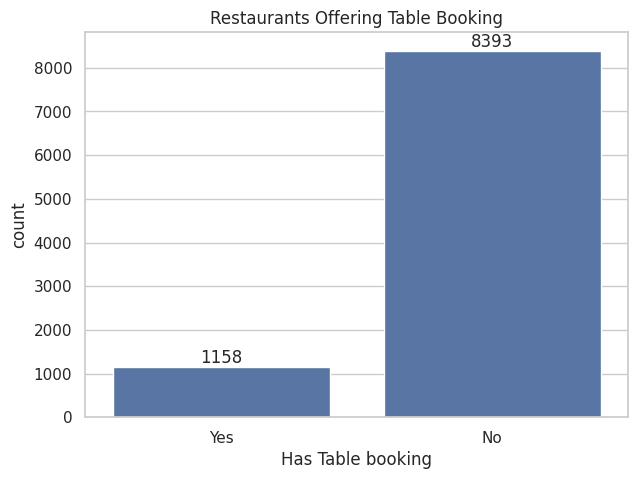

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Has Table booking"
)

plt.title("Restaurants Offering Table Booking")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

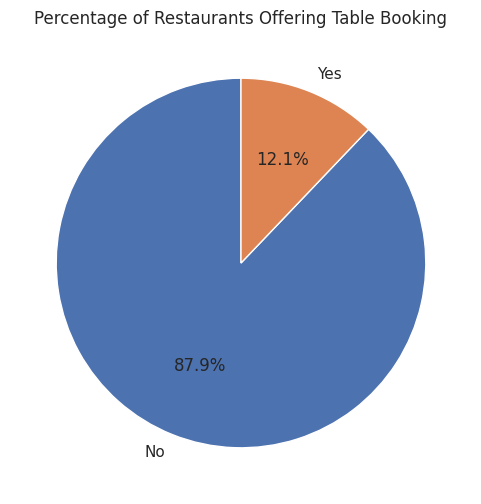

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    table_booking,
    labels=table_booking.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Restaurants Offering Table Booking")

plt.show()

In [ ]:
delivery = df["Has Online delivery"].value_counts()

delivery

,count
Has Online delivery,
No,7100
Yes,2451


In [ ]:
delivery_percent = (
    df["Has Online delivery"]
    .value_counts(normalize=True)
    *100
).round(2)

delivery_percent

,proportion
Has Online delivery,
No,74.34
Yes,25.66


In [ ]:
delivery_summary = pd.DataFrame({
    "Restaurant Count":delivery,
    "Percentage":delivery_percent
})

delivery_summary

,Restaurant Count,Percentage
Has Online delivery,,
No,7100,74.34
Yes,2451,25.66


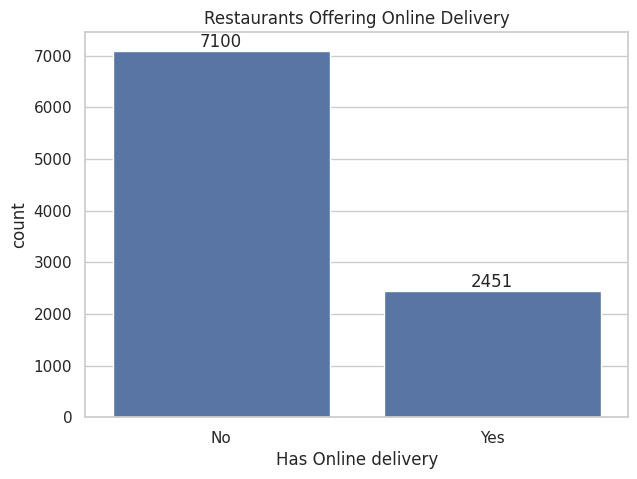

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Has Online delivery"
)

plt.title("Restaurants Offering Online Delivery")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

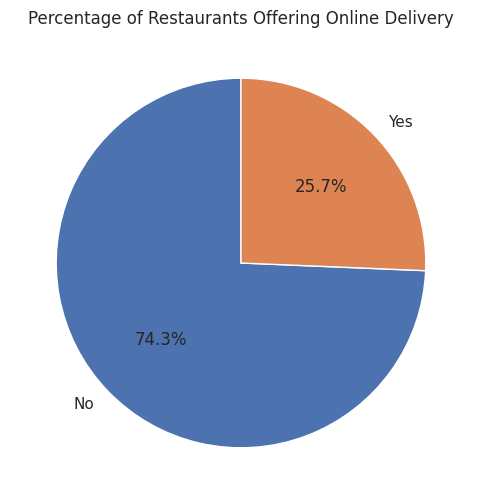

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    delivery,
    labels=delivery.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Restaurants Offering Online Delivery")

plt.show()

In [ ]:
booking_rating = (
    df.groupby("Has Table booking")["Aggregate rating"]
    .mean()
    .round(2)
)

booking_rating

,Aggregate rating
Has Table booking,
No,2.56
Yes,3.44


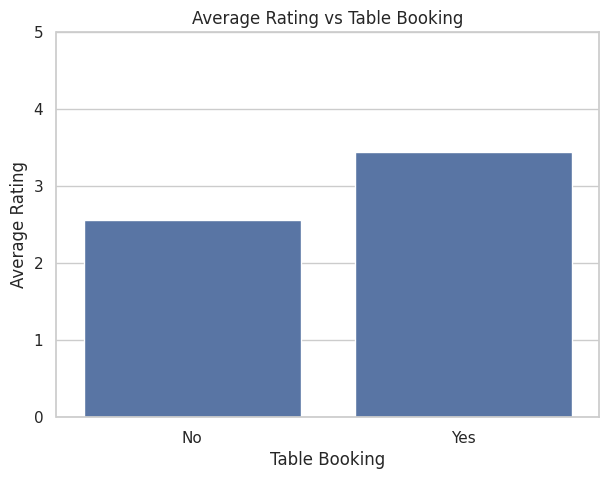

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=booking_rating.index,
    y=booking_rating.values
)

plt.title("Average Rating vs Table Booking")

plt.xlabel("Table Booking")

plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.show()

In [ ]:
delivery_rating = (
    df.groupby("Has Online delivery")["Aggregate rating"]
    .mean()
    .round(2)
)

delivery_rating

,Aggregate rating
Has Online delivery,
No,2.47
Yes,3.25


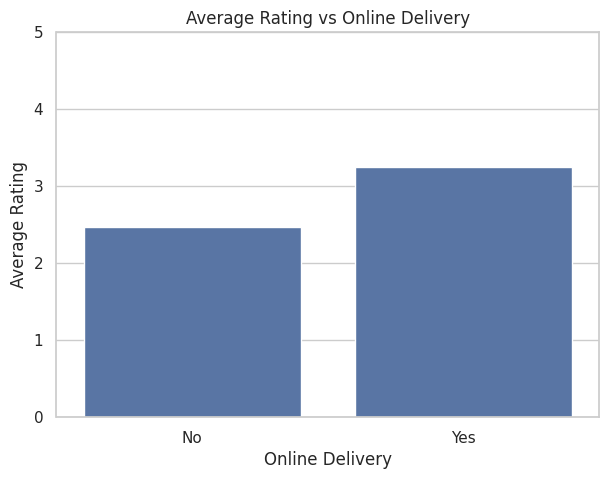

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=delivery_rating.index,
    y=delivery_rating.values
)

plt.title("Average Rating vs Online Delivery")

plt.xlabel("Online Delivery")

plt.ylabel("Average Rating")

plt.ylim(0,5)

plt.show()

In [ ]:
price_delivery = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

price_delivery

Has Online delivery,No,Yes
Price range,,
1,3743,701
2,1827,1286
3,997,411
4,533,53


In [ ]:
price_delivery_percent = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
)*100

price_delivery_percent.round(2)

Has Online delivery,No,Yes
Price range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


In [ ]:
price_mapping = {
    1:"Budget",
    2:"Affordable",
    3:"Premium",
    4:"Luxury"
}

df["Price Category"] = df["Price range"].map(price_mapping)

In [ ]:
price_delivery = pd.crosstab(
    df["Price Category"],
    df["Has Online delivery"],
    normalize="index"
)*100

price_delivery

Has Online delivery,No,Yes
Price Category,,
Affordable,58.689367,41.310633
Budget,84.225923,15.774077
Luxury,90.955631,9.044369
Premium,70.809659,29.190341


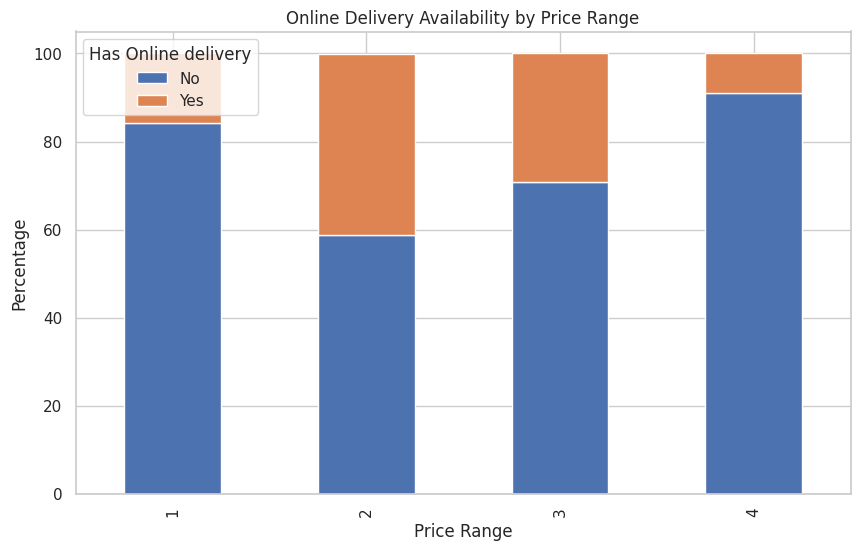

In [ ]:
price_delivery_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Online Delivery Availability by Price Range")

plt.xlabel("Price Range")

plt.ylabel("Percentage")

plt.show()

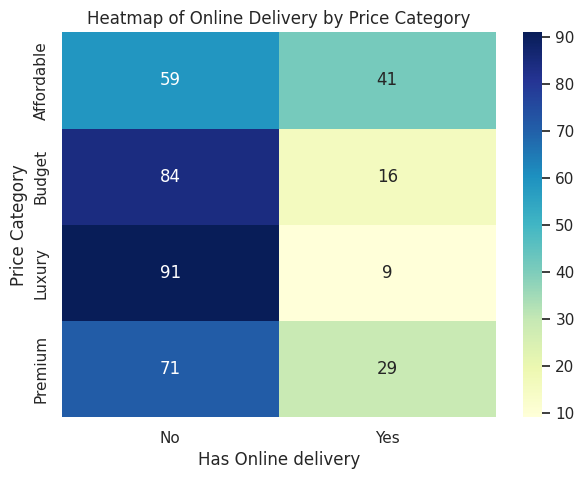

In [ ]:
heatmap = pd.crosstab(
    df["Price Category"],
    df["Has Online delivery"],
    normalize="index"
)*100

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Heatmap of Online Delivery by Price Category")

plt.show()

# Business Insights

1. Only a portion of restaurants provide table booking, indicating that reservation services are not universally adopted.

2. Online delivery is offered by many restaurants, reflecting the growing demand for food delivery services.

3. Restaurants offering table booking generally receive higher average ratings, suggesting that premium customer services may positively influence customer satisfaction.

4. Online delivery availability varies across price categories, with affordable and premium restaurants showing higher adoption rates.

5. Service features such as reservations and delivery can improve customer convenience and may contribute to better restaurant performance.

# Conclusion

This analysis explored the availability of table booking and online delivery services among restaurants. The results showed how these services differ across restaurants and price categories.

Restaurants providing additional customer services generally demonstrated better customer ratings. These findings suggest that convenience-focused features may improve customer satisfaction and influence restaurant success.

In [ ]:
service_summary = (
    df.groupby(
        ["Has Table booking","Has Online delivery"]
    )["Aggregate rating"]
    .mean()
    .round(2)
    .reset_index()
)

service_summary

,Has Table booking,Has Online delivery,Aggregate rating
0,No,No,2.37
1,No,Yes,3.17
2,Yes,No,3.35
3,Yes,Yes,3.60
